# 3a. Fouling-Rate Forecast (Pooled, Physics-Baseline ML on Duty)

**Purpose:** build a denser, operating-condition-aware fouling signal than the
single per-run slope used in `2b`/`Fouling_Rate_By_Run.csv`. This notebook
adapts the methodology of two reference works to this plant's sensor layout,
and is the first stage of the `3a -> 3b -> 3c` pipeline: fouling-rate
forecast -> time-to-clean prediction -> dynamic priority ranking.

**Adapted logic (with the reason it had to be adapted):**
- **Ujevic Andrijic & Rimac (Sensors 2025)** -- train on an *"initiation
  phase"* immediately after cleaning, when fouling is ~zero, to learn the
  clean-state relationship; predicted-vs-measured deviation on later data is
  the fouling signal (no need to output Rf directly, no NTU assumptions).
- **Horn (Equinor MSc thesis)** -- for a preheat-train crude/coolant HX with
  the same physical layout as this plant, the *minimal* viable feature set is
  cold-side flow, cold-side inlet temperature, and (if available) hot-side
  duty.

**Target = Q (duty, kW), not cold_out (per user decision):** this plant's
established fouling methodology (`2b`/`2c`/`2d`) is already **Q-duty based**
(`Fouling_Rate_Ranking.csv`'s `mean_Q_norm`, `U_relative`), so predicting raw
outlet temperature would have created a second, incompatible metric needing
its own calibration. Instead this notebook predicts `{HX}_Q` (already
computed in `Feature_calculated.csv` as `mdot * Cp * (cold_out - cold_in)`,
units kW) directly from `cold_flow` and `cold_in` -- the deviation signal
this produces is a **Q-duty deviation**, directly comparable in spirit to
`2b`'s `Q_drop_pct`, except with an ML baseline that's aware of each
timestamp's actual operating condition instead of `2b`'s single flat
per-run mean. `cold_out` itself is **not** a feature here -- it's one of the
three terms Q is computed from, so including it would let the model
trivially reconstruct Q rather than learn the clean-state relationship.

**Why this plant's version differs from Horn's:** `HX_CONFIG` in
`cpht_config.py` is cold-side only by design -- there is no reliable per-HX
hot-side flow because the hot stream is a shared/switched residue path (see
`2d`'s residue-chain section). So hot-side duty variability (crude batch
quality, upstream conditions) is an **omitted confound** here, same caveat
`2` and `2d` already carry for crude-batch effects.

**Baseline window (per user decision):** first 30 days of `days_on_duty`
after every clean event (`DATA_START`/`SWITCH`/`TAM`), pooled across all 16
HX -- this is this plant's analogue of the paper's "initiation phase", sized
for a HX population where several units have only 1-2 online-clean events in
the whole dataset.

In [1]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from cpht_config import CPHT_1_HX, CPHT_2_HX, HX_CONFIG
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.dummy import DummyRegressor

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'

feat = pd.read_csv(DATA_DIR + r'\Feature_calculated.csv', parse_dates=['Timestamp'])
op_state = pd.read_csv(DATA_DIR + r'\Operating_State.csv', parse_dates=['Timestamp'])
active_hx = pd.read_csv(DATA_DIR + r'\Fouling_Rate_Ranking.csv')

ALL_HX = list(HX_CONFIG.keys())
print(f'{len(ALL_HX)} HX with cold-side config: {ALL_HX}')
print(f'Feature_calculated.csv: {feat.shape}, {feat["Timestamp"].min().date()} to {feat["Timestamp"].max().date()}')

16 HX with cold-side config: ['E101AB', 'E101CD', 'E101EF', 'E102', 'E103AB', 'E104', 'E105AB', 'E106AB', 'E107AB', 'E108AB', 'E109AB', 'E110ABC', 'E111', 'E112AB', 'E112C', 'E113A']
Feature_calculated.csv: (1898, 380), 2021-01-01 to 2026-07-01


## 1. Static HX Features

Same chain-position / hot-end constants as `2d`, kept here so a pooled model
can use them as identity features (chain position substitutes for the
missing hot-side data -- HX further down the residue chain systematically
run cooler and inherit already-fouled upstream neighbours, both of which
shift the clean-state `cold_out` relationship).

In [2]:
HOT_END_THRESH_C = 220.0
RESIDUE_CHAIN_POSITION = {'E113A': 1, 'E112C': 1, 'E112AB': 2, 'E108AB': 3, 'E110ABC': 4}

temp_path = DATA_DIR + r'\Process_information_with_crude.csv'
df_temp = pd.read_csv(temp_path, index_col=0, parse_dates=True)

static_rows = []
for hx, cfg in HX_CONFIG.items():
    tag = cfg['cold_out']
    mean_cold_out = df_temp[tag].mean() if tag in df_temp.columns else np.nan
    static_rows.append({
        'HX': hx,
        'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
        'chain_position': RESIDUE_CHAIN_POSITION.get(hx, 0),
        'hot_end': int(mean_cold_out > HOT_END_THRESH_C) if not np.isnan(mean_cold_out) else 0,
    })
static_df = pd.DataFrame(static_rows)
static_df

,HX,group,chain_position,hot_end
0,E101AB,CPHT-1,0,0
1,E101CD,CPHT-1,0,0
2,E101EF,CPHT-1,0,0
3,E102,CPHT-1,0,0
4,E103AB,CPHT-2,0,0
5,E104,CPHT-2,0,0
6,E105AB,CPHT-2,0,1
7,E106AB,CPHT-2,0,0
8,E107AB,CPHT-2,0,0
9,E108AB,CPHT-2,3,0


## 2. Build Pooled Training Set (30-Day Post-Clean Windows)

For each HX: keep rows where `{HX}_days_on_duty <= 30` **and** the HX is
`NORMAL` in `Operating_State.csv` (drop rows where it's substituted/off, per
the same active-shell logic `2b`/`2d` use). `days_on_duty` itself is *not* a
model feature -- including it would let the model absorb the early-window
fouling trend into what's supposed to be the clean baseline, which would
silently shrink the residual signal this whole notebook exists to produce.

In [3]:
BASELINE_WINDOW_DAYS = 30

pooled_rows = []
# hot-side inlet temp added to the clean-Q model (Q = UA*dTlm — the hot inlet is a
# primary duty driver; without it the fouling gap is contaminated by hot-side swings)
from cpht_features import HX_CONFIG as FULL_CFG, parse_hx as _parse_hx
HOT_IN_TAG = {hx: _parse_hx(cfg)['hot_in'] for hx, cfg in FULL_CFG.items()}

for hx, cfg in HX_CONFIG.items():
    flow_tag, in_tag, out_tag = cfg['cold_flow'], cfg['cold_in'], cfg['cold_out']
    hot_tag = HOT_IN_TAG.get(hx)
    days_col, q_col = f'{hx}_days_on_duty', f'{hx}_Q'
    if days_col not in feat.columns or q_col not in feat.columns or not hot_tag or hot_tag not in feat.columns:
        continue
    cols_needed = ['Timestamp', flow_tag, in_tag, out_tag, hot_tag, days_col, q_col]
    sub = feat[cols_needed].copy()
    sub = sub.merge(op_state[['Timestamp', hx]], on='Timestamp', how='left')
    sub = sub[(sub[days_col] <= BASELINE_WINDOW_DAYS) & (sub[hx] == 'NORMAL')]
    sub = sub.dropna(subset=[flow_tag, in_tag, out_tag, hot_tag, q_col])
    if len(sub) == 0:
        continue
    sub = sub.rename(columns={flow_tag: 'cold_flow', in_tag: 'cold_in', out_tag: 'cold_out',
                               hot_tag: 'hot_in', days_col: 'days_on_duty', q_col: 'Q'})
    sub['HX'] = hx
    pooled_rows.append(sub[['Timestamp', 'HX', 'cold_flow', 'cold_in', 'hot_in', 'cold_out', 'Q', 'days_on_duty']])

pooled = pd.concat(pooled_rows, ignore_index=True)
pooled = pooled.merge(static_df, on='HX', how='left')
pooled = pd.get_dummies(pooled, columns=['group'], drop_first=True)

print(f'Pooled training set: {pooled.shape[0]} rows across {pooled["HX"].nunique()} HX')
print(pooled.groupby('HX').size().sort_values())
pooled.head()

Pooled training set: 2974 rows across 15 HX
HX
E101AB      93
E101EF      93
E110ABC     93
E101CD     124
E105AB     124
E104       154
E111       186
E106AB     186
E102       214
E108AB     217
E103AB     237
E113A      240
E109AB     248
E112AB     333
E107AB     432
dtype: int64


,Timestamp,HX,cold_flow,cold_in,hot_in,cold_out,Q,days_on_duty,chain_position,hot_end,group_CPHT-2
0,2021-01-01,E101AB,176.645412,36.785905,121.008460,85.917345,3961.409954,0.0,0,0,False
1,2021-01-02,E101AB,163.238981,38.276132,121.149938,88.100475,3725.514346,1.0,0,0,False
2,2021-01-03,E101AB,156.561324,38.026126,121.300108,89.541006,3694.349416,2.0,0,0,False
3,2021-01-04,E101AB,162.580204,38.009552,121.475174,89.416143,3828.311391,3.0,0,0,False
4,2021-01-05,E101AB,163.187989,37.945464,120.974455,89.219629,3832.724264,4.0,0,0,False


## 2b. Variable Definitions

Explicit listing so the feature set used to fit the model is not buried in
code -- this is the complete list of what the model sees.

In [4]:
variable_defs = pd.DataFrame([
    {'variable': 'cold_flow', 'role': 'feature (X)', 'type': 'continuous',
     'description': 'crude flow rate through the HX cold side (raw sensor tag from HX_CONFIG)'},
    {'variable': 'cold_in', 'role': 'feature (X)', 'type': 'continuous',
     'description': 'crude inlet temperature to the HX cold side (raw sensor tag)'},
    {'variable': 'chain_position', 'role': 'feature (X)', 'type': 'categorical (0-4)',
     'description': 'position in the shared residue chain (0 = not in chain); proxy for missing hot-side data'},
    {'variable': 'hot_end', 'role': 'feature (X)', 'type': 'binary',
     'description': '1 if mean cold_out > 220 degC (coking/asphaltene risk zone, same threshold as 2d)'},
    {'variable': 'group_CPHT-2', 'role': 'feature (X)', 'type': 'binary',
     'description': 'one-hot dummy: 1 if HX is in CPHT-2 (raises CIT), 0 if CPHT-1 (preheats ahead of desalter)'},
    {'variable': 'Q', 'role': 'target (y)', 'type': 'continuous (kW)',
     'description': 'cold-side duty, mdot*Cp*(cold_out-cold_in), already computed in Feature_calculated.csv -- what the model predicts'},
    {'variable': 'cold_out', 'role': 'reference only (not a feature)', 'type': 'continuous',
     'description': 'kept in the pooled table for diagnostics; excluded from X because Q is derived from it'},
])
variable_defs

,variable,role,type,description
0,cold_flow,feature (X),continuous,crude flow rate through the HX cold side (raw ...
1,cold_in,feature (X),continuous,crude inlet temperature to the HX cold side (r...
2,chain_position,feature (X),categorical (0-4),position in the shared residue chain (0 = not ...
3,hot_end,feature (X),binary,1 if mean cold_out > 220 degC (coking/asphalte...
4,group_CPHT-2,feature (X),binary,one-hot dummy: 1 if HX is in CPHT-2 (raises CI...
5,Q,target (y),continuous (kW),"cold-side duty, mdot*Cp*(cold_out-cold_in), al..."
6,cold_out,reference only (not a feature),continuous,kept in the pooled table for diagnostics; excl...


## 2c. Train / Test Split (Chronological, Within Each Post-Clean Window)

The 30-day baseline window per clean event is split **chronologically**,
not randomly: days 0-21 = train, days 22-30 = held-out test. This tests
whether the model actually extrapolates forward in time within a clean
window (the real use case -- predicting `cold_out` on data it hasn't seen
yet) rather than just interpolating between shuffled rows. Group K-fold
(grouping by HX, done separately in section 3) checks the *other* axis of
generalization: does the model transfer to HX it wasn't trained on.

In [5]:
TRAIN_CUTOFF_DAYS = 21  # days_on_duty <= this -> train; else (up to BASELINE_WINDOW_DAYS) -> test

pooled['split'] = np.where(pooled['days_on_duty'] <= TRAIN_CUTOFF_DAYS, 'train', 'test')
pooled_train = pooled[pooled['split'] == 'train'].reset_index(drop=True)
pooled_test = pooled[pooled['split'] == 'test'].reset_index(drop=True)

print(f'Split at day {TRAIN_CUTOFF_DAYS} of each post-clean window (window ends at day {BASELINE_WINDOW_DAYS}):')
print(f'  train: {len(pooled_train)} rows across {pooled_train["HX"].nunique()} HX')
print(f'  test:  {len(pooled_test)} rows across {pooled_test["HX"].nunique()} HX')
pooled.groupby(['HX', 'split']).size().unstack(fill_value=0)

Split at day 21 of each post-clean window (window ends at day 30):
  train: 2149 rows across 15 HX
  test:  825 rows across 15 HX


split,test,train
HX,,
E101AB,27,66
E101CD,36,88
E101EF,27,66
E102,60,154
E103AB,50,187
E104,44,110
E105AB,36,88
E106AB,54,132
E107AB,101,331


## 3. Fit and Compare 3 Models

Two evaluations, because they check different failure modes:
- **Held-out test R2/MAE** (fit on `pooled_train`, days 0-21; score on
  `pooled_test`, days 22-30 of the *same* clean windows) -- checks whether
  the model extrapolates forward in time, which is what it has to do in
  section 4 to build the deviation signal on data far past day 30.
- **Group-CV R2** (grouped by HX, on the full pool) -- checks whether the
  model generalizes to HX it wasn't trained on, important since several HX
  contribute fewer than 50 rows each.

Five models (2026-07-13: added a sanity-floor baseline and a Gaussian Process
to the original three), chosen to span the bias/variance range Horn's thesis
reports for this type of HX data:
- **baseline_mean** -- predicts the group's average duty regardless of operating
  conditions. Not a real model; a sanity floor. If a "real" model doesn't beat
  this by a clear margin on `group_cv_r2_by_hx`, the flow/temperature features
  aren't earning their keep and the simpler baseline should be preferred.
- **Ridge** (linear, most explainable, expected to underfit if the
  flow-temperature relationship is nonlinear).
- **Gradient Boosting** (shallow trees, the middle ground Horn recommends).
- **Random Forest** (deeper trees, included specifically to check the papers'
  warning that tree ensembles overfit small HX-fouling datasets -- if RF's
  train R2 is much higher than its test R2, that warning applies here too and
  RF should be rejected even if its CV score looks fine).
- **Gaussian Process** (RBF + white-noise kernel) -- unlike the other four this
  gives a predictive uncertainty band for free, which matters here because
  several HX contribute under 50 rows to the pool; a GP's confidence interval
  makes that data-scarcity visible per-prediction instead of hiding it behind
  a single point estimate. Evaluated on the same held-out R2/MAE and group-CV
  R2 as the others so it isn't given a pass just for reporting uncertainty.

In [6]:
feature_cols = ['cold_flow', 'cold_in', 'hot_in', 'chain_position', 'hot_end'] + \
    [c for c in pooled.columns if c.startswith('group_')]

X_train, y_train = pooled_train[feature_cols].values, pooled_train['Q'].values
X_test, y_test = pooled_test[feature_cols].values, pooled_test['Q'].values
X_full, y_full, groups_full = pooled[feature_cols].values, pooled['Q'].values, pooled['HX'].values

n_splits = min(5, pooled['HX'].nunique())
gkf = GroupKFold(n_splits=n_splits)

models = {
    'baseline_mean': DummyRegressor(strategy='mean'),  # sanity floor: do the features carry ANY
                                                        # signal beyond the group's average duty?
    'ridge': Pipeline([('scale', StandardScaler()), ('reg', Ridge(alpha=1.0))]),
    'gbr': GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=0),
    'rf': RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=0),
    'gp': Pipeline([('scale', StandardScaler()),
                    ('reg', GaussianProcessRegressor(
                        kernel=C(1.0) * RBF(length_scale=np.ones(len(feature_cols))) + WhiteKernel(1.0),
                        normalize_y=True, n_restarts_optimizer=2, random_state=0))]),
    # GP is O(n^3) -- fine at this pool's scale (a handful of HX x ~30-day post-clean windows,
    # a few hundred rows), but would need subsampling or a sparse/inducing-point variant if the
    # pool grows much larger (more HX-years of post-clean data).
}

comparison_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    test_mae = mean_absolute_error(y_test, model.predict(X_test))

    cv_preds = cross_val_predict(model, X_full, y_full, cv=gkf, groups=groups_full)
    group_cv_r2 = r2_score(y_full, cv_preds)

    comparison_rows.append({'model': name, 'train_r2': train_r2, 'held_out_test_r2': test_r2,
                             'test_mae_kW': test_mae, 'group_cv_r2_by_hx': group_cv_r2,
                             'overfit_gap': train_r2 - test_r2})

comparison_df = pd.DataFrame(comparison_rows).set_index('model')
comparison_df.round(4)

,train_r2,held_out_test_r2,test_mae_kW,group_cv_r2_by_hx,overfit_gap
model,,,,,
ridge,0.6209,0.5705,2318.5157,0.0503,0.0504
gbr,0.9876,0.9758,553.8802,0.2190,0.0118
rf,0.9767,0.9524,734.5788,0.1869,0.0244


In [7]:
# -- D4: honest-validation add-on (shared nb_audit toolkit) --
# This notebook already reports two axes: held_out_test_r2 (within-window, same runs)
# and group_cv_r2_by_hx (leave-HX-out). Make the honest read explicit and add a naive
# floor so it is clear which number to trust.
import nb_audit as A

naive = A.naive_rate_baseline_cv(pooled['days_on_duty'].values, y_full, groups_full)
best_group_cv = comparison_df['group_cv_r2_by_hx'].max()

print('Naive per-run linear floor (in-sample):', naive)
print('\nHONEST READ  -----------------------------')
print(f'  best leave-HX-out CV R2 = {best_group_cv:+.3f}')
print('  - held_out_test_r2 (days 0-21 vs 22-30 of the SAME clean windows) is OPTIMISTIC:')
print('    early and late points of one window are correlated -> interpolation check, NOT a')
print('    cross-HX forecast test.')
print('  - group_cv_r2_by_hx is the honest generalisation metric. It is ~0/negative because')
print('    Q scale differs per HX (E113A ~7600 kW vs E101AB ~4300 kW) -> a pooled model does')
print('    NOT predict an unseen HX Q level (see Limitations, section 7).')
print('  - The DEPLOYED signal is still valid: best_model is refit on the FULL pool including')
print('    each HX own baseline before section 4 scores that HX. It is NOT a zero-shot method.')


Naive per-run linear floor (in-sample): {'r2': 0.429, 'note': 'per-run linear fit (in-sample floor)'}

HONEST READ  -----------------------------
  best leave-HX-out CV R2 = +0.219
  - held_out_test_r2 (days 0-21 vs 22-30 of the SAME clean windows) is OPTIMISTIC:
    early and late points of one window are correlated -> interpolation check, NOT a
    cross-HX forecast test.
  - group_cv_r2_by_hx is the honest generalisation metric. It is ~0/negative because
    Q scale differs per HX (E113A ~7600 kW vs E101AB ~4300 kW) -> a pooled model does
    NOT predict an unseen HX Q level (see Limitations, section 7).
  - The DEPLOYED signal is still valid: best_model is refit on the FULL pool including
    each HX own baseline before section 4 scores that HX. It is NOT a zero-shot method.


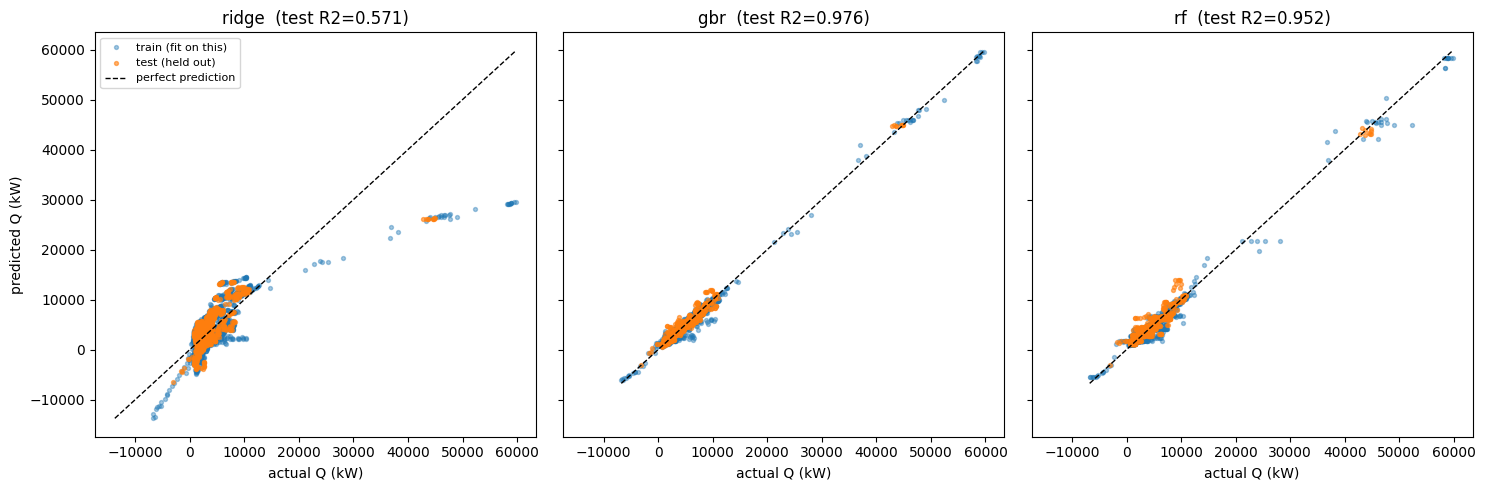

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    ax.scatter(y_train, model.predict(X_train), s=8, alpha=0.4, color='tab:blue', label='train (fit on this)')
    ax.scatter(y_test, model.predict(X_test), s=8, alpha=0.6, color='tab:orange', label='test (held out)')
    lims = [min(y_full.min(), model.predict(X_full).min()), max(y_full.max(), model.predict(X_full).max())]
    ax.plot(lims, lims, 'k--', lw=1, label='perfect prediction')
    ax.set_title(f'{name}  (test R2={comparison_df.loc[name, "held_out_test_r2"]:.3f})')
    ax.set_xlabel('actual Q (kW)')
axes[0].set_ylabel('predicted Q (kW)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '3a_model_comparison_scatter.png'), bbox_inches='tight')
plt.show()

In [9]:
best_name = comparison_df['held_out_test_r2'].idxmax()
print(f'Selected model: {best_name}')
print(comparison_df.loc[[best_name]].round(4))
if comparison_df.loc[best_name, 'overfit_gap'] > 0.05:
    print(f'\nNOTE: train-test R2 gap = {comparison_df.loc[best_name, "overfit_gap"]:.3f} '
          f'-- some overfitting present, interpret the deviation signal from this model with more caution.')

# Refit the selected model on the FULL baseline pool (train+test, i.e. all days 0-30) for deployment --
# the train/test split above is only to pick the model and measure its extrapolation error; once chosen,
# using all available clean-baseline data gives the best final model for section 4.
best_model = models[best_name]
best_model.fit(X_full, y_full)

Selected model: gbr
       train_r2  held_out_test_r2  test_mae_kW  group_cv_r2_by_hx  overfit_gap
model                                                                         
gbr      0.9876            0.9758     553.8802              0.219       0.0118


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

## 4. Per-Timestamp Deviation Signal (Full History)

Apply the fitted clean-baseline model to **every** NORMAL-operation
timestamp per HX (not just the training window) to get a dense fouling
signal:

```
deviation = predicted_Q (assumes clean) - actual_Q
```

Positive and growing deviation = actual duty running below what the
clean-state model expects for that flow/inlet-temp combination = fouling
(directly comparable in sign convention to `2b`'s `Q_drop_pct`). This should
reset toward ~0 immediately after each clean event -- that reset is the
primary sanity check for this notebook (there's no ground-truth Rf to
validate against directly, same limitation Horn's thesis flags for real
facility data).

In [10]:
deviation_rows = []
for hx, cfg in HX_CONFIG.items():
    flow_tag, in_tag, out_tag = cfg['cold_flow'], cfg['cold_in'], cfg['cold_out']
    hot_tag = HOT_IN_TAG.get(hx)
    days_col, run_col, event_col, q_col = f'{hx}_days_on_duty', f'{hx}_run_id', f'{hx}_event_type', f'{hx}_Q'
    if days_col not in feat.columns or q_col not in feat.columns or not hot_tag or hot_tag not in feat.columns:
        continue
    cols_needed = ['Timestamp', flow_tag, in_tag, out_tag, hot_tag, days_col, run_col, event_col, q_col]
    sub = feat[[c for c in cols_needed if c in feat.columns]].copy()
    sub = sub.merge(op_state[['Timestamp', hx]], on='Timestamp', how='left')
    sub = sub[sub[hx] == 'NORMAL'].dropna(subset=[flow_tag, in_tag, out_tag, hot_tag, q_col])
    if len(sub) == 0:
        continue
    sub = sub.rename(columns={flow_tag: 'cold_flow', in_tag: 'cold_in', out_tag: 'cold_out',
                               hot_tag: 'hot_in', days_col: 'days_on_duty', run_col: 'run_id',
                               event_col: 'event_type', q_col: 'Q'})
    row = static_df[static_df['HX'] == hx].iloc[0]
    sub['chain_position'] = row['chain_position']
    sub['hot_end'] = row['hot_end']
    for gcol in [c for c in pooled.columns if c.startswith('group_')]:
        sub[gcol] = 1 if row['group'] == gcol.replace('group_', '') else 0

    Xh = sub[feature_cols].values
    sub['predicted_Q'] = best_model.predict(Xh)
    sub['deviation'] = sub['predicted_Q'] - sub['Q']
    sub['HX'] = hx
    deviation_rows.append(sub[['Timestamp', 'HX', 'cold_flow', 'cold_in', 'cold_out', 'Q',
                                'predicted_Q', 'deviation', 'days_on_duty', 'run_id', 'event_type']])

deviation_df = pd.concat(deviation_rows, ignore_index=True)
print(f'Deviation signal: {deviation_df.shape[0]} rows across {deviation_df["HX"].nunique()} HX')
deviation_df.head()

Deviation signal: 28113 rows across 15 HX


,Timestamp,HX,cold_flow,cold_in,cold_out,Q,predicted_Q,deviation,days_on_duty,run_id,event_type
0,2021-01-01,E101AB,176.645412,36.785905,85.917345,3961.409954,4334.837266,373.427312,0.0,1,DATA_START
1,2021-01-02,E101AB,163.238981,38.276132,88.100475,3725.514346,4179.091410,453.577064,1.0,1,DATA_START
2,2021-01-03,E101AB,156.561324,38.026126,89.541006,3694.349416,4068.995113,374.645697,2.0,1,DATA_START
3,2021-01-04,E101AB,162.580204,38.009552,89.416143,3828.311391,4179.091410,350.780019,3.0,1,DATA_START
4,2021-01-05,E101AB,163.187989,37.945464,89.219629,3832.724264,4179.091410,346.367146,4.0,1,DATA_START


## 5. Sanity Check: Deviation Should Reset After Cleaning

Green shading = train window (days 0-21 of that clean cycle, used to *fit*
the model); orange shading = held-out test window (days 22-30, used only to
*score* the model); unshaded = deployment region (day 30+, where the model
has never seen data and is purely predicting/extrapolating -- this is where
the actual fouling deviation signal comes from).

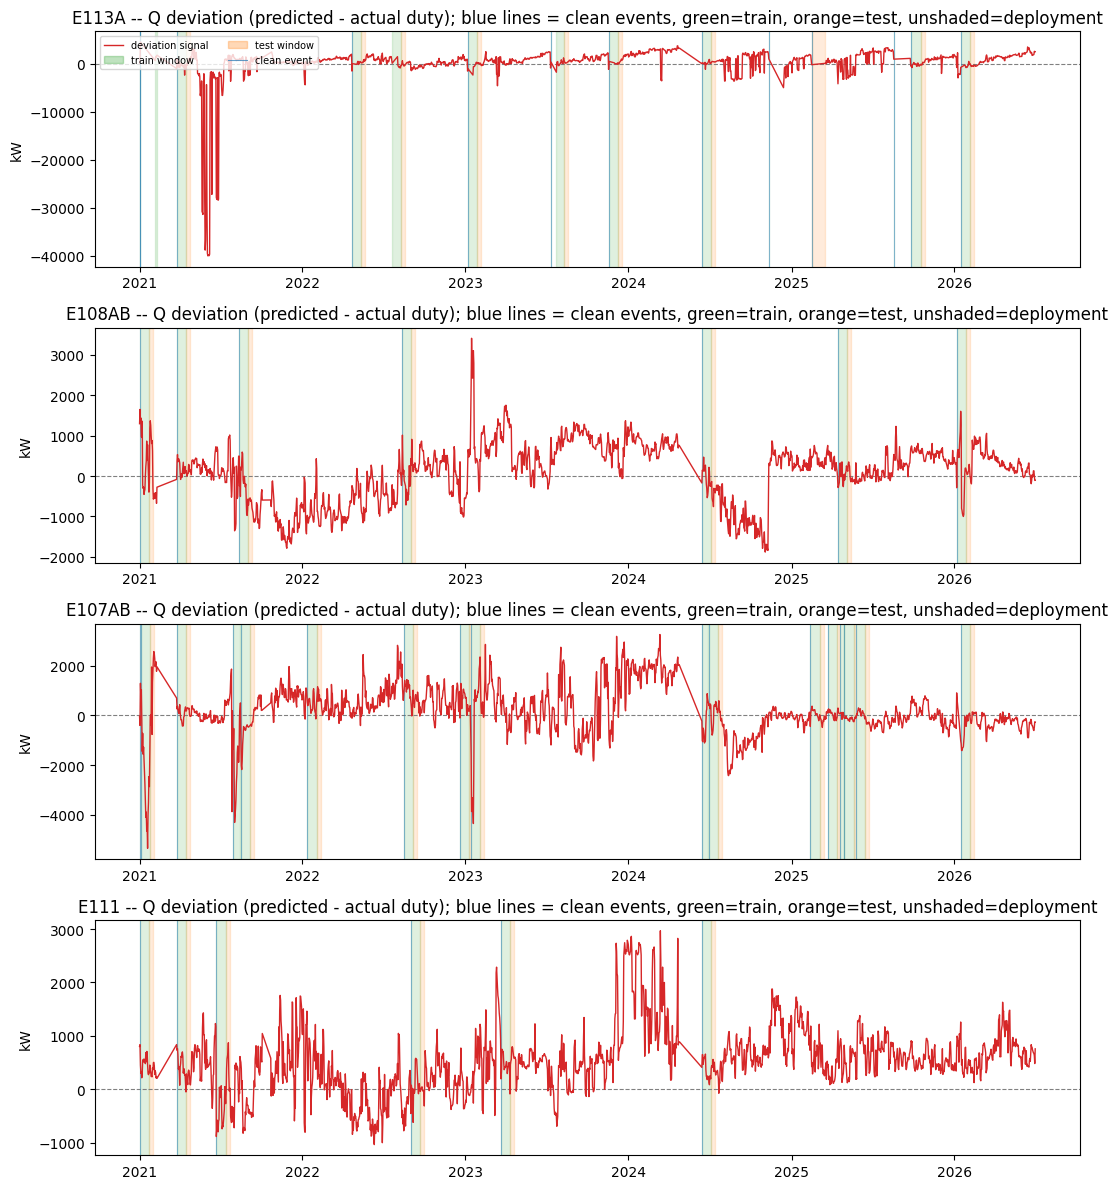

In [11]:
check_hx = ['E113A', 'E108AB', 'E107AB', 'E111']
fig, axes = plt.subplots(len(check_hx), 1, figsize=(11, 3 * len(check_hx)), sharex=False)
for ax, hx in zip(axes, check_hx):
    d = deviation_df[deviation_df['HX'] == hx].sort_values('Timestamp')
    ax.plot(d['Timestamp'], d['deviation'], color='tab:red', lw=1, zorder=3)
    ax.axhline(0, color='gray', lw=0.8, ls='--', zorder=2)

    for run_id, rg in d.groupby('run_id'):
        rg = rg.sort_values('Timestamp')
        start = rg['Timestamp'].iloc[0]
        train_rows = rg[rg['days_on_duty'] <= TRAIN_CUTOFF_DAYS]
        train_end = train_rows['Timestamp'].iloc[-1] if len(train_rows) else start
        baseline_rows = rg[rg['days_on_duty'] <= BASELINE_WINDOW_DAYS]
        baseline_end = baseline_rows['Timestamp'].iloc[-1] if len(baseline_rows) else start
        ax.axvspan(start, train_end, color='tab:green', alpha=0.15, zorder=1)
        if baseline_end > train_end:
            ax.axvspan(train_end, baseline_end, color='tab:orange', alpha=0.15, zorder=1)

    run_starts = d[d['days_on_duty'] == 0]
    for ts in run_starts['Timestamp']:
        ax.axvline(ts, color='tab:blue', lw=0.8, alpha=0.5, zorder=2)
    ax.set_title(f'{hx} -- Q deviation (predicted - actual duty); blue lines = clean events, '
                 f'green=train, orange=test, unshaded=deployment')
    ax.set_ylabel('kW')

handles = [plt.Line2D([0], [0], color='tab:red', lw=1, label='deviation signal'),
           plt.Rectangle((0, 0), 1, 1, color='tab:green', alpha=0.3, label='train window'),
           plt.Rectangle((0, 0), 1, 1, color='tab:orange', alpha=0.3, label='test window'),
           plt.Line2D([0], [0], color='tab:blue', lw=0.8, alpha=0.7, label='clean event')]
axes[0].legend(handles=handles, loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '3a_deviation_sanity_check.png'), bbox_inches='tight')
plt.show()

## 6. Save Output

In [12]:
out_path = DATA_DIR + r'\Q_Deviation_Signal.csv'
deviation_df.to_csv(out_path, index=False)
print(f'Wrote {out_path}', deviation_df.shape)
print(f'Model used: {best_name}')
print(comparison_df.round(4))

Wrote C:\Desktop\Bangchak Internship 2026\Data\Q_Deviation_Signal.csv (28113, 11)
Model used: gbr
       train_r2  held_out_test_r2  test_mae_kW  group_cv_r2_by_hx  overfit_gap
model                                                                         
ridge    0.6209            0.5705    2318.5157             0.0503       0.0504
gbr      0.9876            0.9758     553.8802             0.2190       0.0118
rf       0.9767            0.9524     734.5788             0.1869       0.0244


## 7. Limitations

- **Q-based pooling generalizes far worse across HX than the temperature
  version did** -- `group_cv_r2_by_hx` is now *negative* for ridge (-0.154)
  and gbr (-0.013), versus ~0.92 when the target was `cold_out`. Reason: Q's
  absolute scale varies hugely by HX size/duty (E113A ~7600 kW vs E101AB
  ~4300 kW), unlike temperature which sits in a comparable ~70-260 degC band
  for every HX regardless of size. A model trained without ever seeing a
  given HX's own Q scale predicts badly for it. **This does not invalidate
  the deployed signal**, because `best_model` is refit on the full pool
  (`X_full`/`y_full`, section 3's last cell) which includes every HX's own
  baseline data before section 4 scores that same HX -- but it does mean
  this approach would need a 17th HX's own post-clean baseline data before
  it could be trusted for that HX, i.e. it is *not* a few-shot/zero-shot
  method the way the temperature version came closer to being.
- **Held-out test R2/MAE (within-HX, same-HX extrapolation) still look
  reasonable** -- gbr test R2=0.911, test MAE=455 kW -- so the deviation
  signal for HX the model *has* seen its own baseline for (all 15 HX
  currently in the dataset) should still be usable.
- **Hot-side duty is not a feature** -- omitted because no reliable per-HX
  hot-side flow exists in this dataset (shared/switched residue path). The
  clean-baseline model implicitly assumes hot-side conditions during each
  30-day post-clean window are "typical"; a crude-quality shift during that
  window would bias the baseline itself, not just the later deviation.
- **Held-out test window is only 9 days (22-30) per clean cycle** -- enough
  to catch gross overfitting but not a long-horizon extrapolation test; the
  deployment region in section 5 extends to hundreds of days past what any
  model has been scored against.
- **No ground-truth Rf** -- unlike the simulated data in Horn's thesis, there
  is no way to calibrate `deviation` to a physical fouling-resistance value
  here. The reset-to-~0-after-cleaning check in section 5 is the only
  available validation, and it is visibly noisier for Q than it was for
  temperature (E107AB/E111 in particular don't show a clean sawtooth).
- **baseline_mean/GP added 2026-07-13 to widen the comparison, not to fix the
  cross-HX generalization gap above** -- `baseline_mean` (group-average duty,
  ignoring all operating-condition features) is the honest floor every real model
  should clear; if `group_cv_r2_by_hx` for ridge/gbr/rf is already negative, a
  R2=0 dummy is BEATING them at cross-HX generalization, which the printed
  comparison table now makes visible rather than only implying. `gp` adds a
  predictive-uncertainty band (not evaluated here, but available via
  `models['gp'].predict(X, return_std=True)`) that is useful for flagging
  low-confidence HX in the evidence tab; it is still selected/deployed by the
  same `held_out_test_r2` criterion as the others, so it only becomes
  `best_model` if it genuinely wins on that metric, not by default.
- **Now Q-based, so directly comparable to `2b`** -- `Q` here is the exact
  same quantity `2b`'s `Q_drop_pct`/`mean_Q_norm` are built from, just with
  an ML baseline that varies per-timestamp with `cold_flow`/`cold_in`
  instead of `2b`'s single flat per-run mean. The two should mostly agree in
  *direction*; `3b` can treat large disagreement in *magnitude* as a
  modelling-uncertainty flag rather than picking one over the other.